# Source normalization

In this notebook, we will exemplify the three different source normalization schemes used for [PlaneWave](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PlaneWave.html) (as well as [GaussianBeam](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.GaussianBeam.html) and [ModeSource](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSource.html)), [TFSF](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.TFSF.html), and [PointDipole](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PointDipole.html) sources, and how each relates to the magnitude of the electric field, $|E|$. We will also discuss the importance of monitor placement when there are forward and backward fields of nearly equal amplitude.

You can find more information about source normalization on [this](https://docs.flexcompute.com/projects/tidy3d/en/latest/faq/docs/faq/How-are-results-normalized.html) page.

## Table of contents
1. [Simulation setup](#setup)
2. [Plane wave and TFSF normalization](#pw_tfsf)
3. [Placing a normalization monitor](#normalization)
4. [Point dipole normalization](#dipole)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

## Setup <a name="setup"></a>

We will first define global variables and an auxiliary function for returning the simulation object.

In [ ]:
# global variables
freq0 = td.C_0 / 1.5
fwidth = 0.1 * freq0
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)

In [ ]:
# auxiliary function
def get_sim(
    size=1,
    source_type="PW",
    theta_degree=0,
    min_steps_per_wvl=20,
    bloch_medium=td.Medium(permittivity=1),
    pol_angle_degree=0,
    structures=[],
):
    # angle to radian
    theta = np.deg2rad(theta_degree)
    pol_angle = np.deg2rad(pol_angle_degree)

    # flux monitor
    flux_mon = td.FluxMonitor(
        name="flux_mon",
        size=(td.inf, td.inf, 0),
        center=(0, 0, 0),
        freqs=[freq0],
    )

    # field monitor
    field_mon = td.FieldMonitor(
        name="field_mon",
        size=flux_mon.size,
        center=flux_mon.center,
        freqs=flux_mon.freqs,
    )

    # plane wave source
    if source_type == "PW":
        sim_size = (size, size, 4)

        source = td.PlaneWave(
            center=(0, 0, -1),
            size=(td.inf, td.inf, 0),
            direction="+",
            source_time=source_time,
            angle_theta=theta,
            pol_angle=pol_angle,
        )

        # bloch boundaries.
        bloch_x = td.Boundary.bloch_from_source(
            source=source, domain_size=size, axis=0, medium=bloch_medium
        )

        bloch_y = td.Boundary.bloch_from_source(
            source=source, domain_size=size, axis=1, medium=bloch_medium
        )

        bspec = td.BoundarySpec(x=bloch_x, y=bloch_y, z=td.Boundary.pml())

        grid_spec = td.GridSpec.auto(wavelength=1.5, min_steps_per_wvl=min_steps_per_wvl)
        
    # TFSF source
    elif source_type == "TFSF":
        sim_size = (size + 2, size + 2, 4)

        source = td.TFSF(
            center=(0, 0, 0),
            size=(size, size, 2),
            direction="+",
            source_time=source_time,
            injection_axis=2,
            angle_theta=theta,
        )

        mesh_override = td.MeshOverrideStructure(
            geometry=td.Box(center=source.center, size=source.size),
            dl=(0.02,) * 3,
        )
        grid_spec = td.GridSpec.auto(
            wavelength=1.5, min_steps_per_wvl=min_steps_per_wvl, override_structures=[mesh_override]
        )
        bspec = td.BoundarySpec(x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml())

    # creating the simulation object
    sim = td.Simulation(
        size=sim_size,
        boundary_spec=bspec,
        grid_spec=grid_spec,
        run_time=8e-12 / np.cos(theta),
        sources=[source],
        monitors=[flux_mon, field_mon],
        structures=structures,
    )

    return sim

## Plane wave and TFSF normalization <a name="pw_tfsf"></a>

There is an important difference between the normalization of the `TFSF` and `PlaneWave` sources:

- The `PlaneWave` source is normalized to inject **1 W of total power**, regardless of the source plane size.

$$
P_{pw} = 1~\text{W} = \text{constant}
$$

- The `TFSF` source is normalized to inject **1 W/µm² of intensity**. Therefore, the **total power depends on the source plane area**.

$$
I_{TFSF} = \frac{1}{\text{Area}}~\frac{\text{W}}{\mu\text{m}^2}
$$

$$
P_{TFSF} = \text{Area}~[\text{W}]
$$

Relating the field intensity to the electric field amplitude $|E|_0$ via the **Poynting theorem**:

$$
I = |\langle\vec{S}\rangle| = \frac{1}{2}cn\epsilon_0 |E_0|^2~\frac{\text{W}}{\mu\text{m}^2}
$$

we see that an advantage of the `TFSF` normalization is that $|E_0|$ **does not depend on the source size**.

On the other hand, for the `PlaneWave` source, $|E_0|$ is **proportional to the source plane area**.

As a result, the `TFSF` source is often more convenient when calculating **cross sections** and other quantities that depend on $|E_0|$.

We can perform a simple test to illustrate this.

In [4]:
# create a batch of simulations for plane wave and TFSF sources with different sizes
sizes = [0.5, 1, 1.5, 2, 2.5, 3]
sims_PW = {i: get_sim(size=i, source_type="PW") for i in sizes}
sims_TFSF = {i: get_sim(size=i, source_type="TFSF") for i in sizes}

batch_PW = web.Batch(simulations=sims_PW, folder_name="plane_wave_normalization")
batch_TFSF = web.Batch(simulations=sims_TFSF, folder_name="TFSF_normalization")

In [5]:
# running the batch
batch_data_PW = batch_PW.run()
batch_data_TFSF = batch_TFSF.run()

Output()

13:19:25 -03 Started working on Batch containing 6 tasks.

13:20:51 -03 Maximum FlexCredit cost: 0.150 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

...

13:22:49 -03 Maximum FlexCredit cost: 1.369 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

13:22:54 -03 Batch complete.

Output()

In [6]:
# plane wave field
Ex_PW = np.array(
    [batch_data_PW[str(s)]["field_mon"].Ex.sel(x=0, y=0, method="nearest").squeeze() for s in sizes]
)
Ey_PW = np.array(
    [batch_data_PW[str(s)]["field_mon"].Ey.sel(x=0, y=0, method="nearest").squeeze() for s in sizes]
)
Ez_PW = np.array(
    [batch_data_PW[str(s)]["field_mon"].Ez.sel(x=0, y=0, method="nearest").squeeze() for s in sizes]
)
E_PW = np.sqrt(np.abs(Ex_PW) ** 2 + np.abs(Ey_PW) ** 2 + np.abs(Ez_PW) ** 2)

# plane wave flux
flux_PW = [batch_data_PW[str(s)]["flux_mon"].flux.values.squeeze() for s in sizes]

# analytical |E| field for the plane wave
E0_PW = [np.sqrt(2 / (td.C_0 * 1 * td.EPSILON_0 * s**2)) for s in sizes]

# TFSF field
Ex_TFSF = np.array(
    [
        batch_data_TFSF[str(s)]["field_mon"].Ex.sel(x=0, y=0, method="nearest").squeeze()
        for s in sizes
    ]
)
Ey_TFSF = np.array(
    [
        batch_data_TFSF[str(s)]["field_mon"].Ey.sel(x=0, y=0, method="nearest").squeeze()
        for s in sizes
    ]
)
Ez_TFSF = np.array(
    [
        batch_data_TFSF[str(s)]["field_mon"].Ez.sel(x=0, y=0, method="nearest").squeeze()
        for s in sizes
    ]
)
E_TFSF = np.sqrt(np.abs(Ex_TFSF) ** 2 + np.abs(Ey_TFSF) ** 2 + np.abs(Ez_TFSF) ** 2)

# TFSF flux
flux_TFSF = [batch_data_TFSF[str(s)]["flux_mon"].flux.values.squeeze() for s in sizes]

# analytical |E| field for the TFSF source
E0_TFSF = [np.sqrt(2 / (td.C_0 * 1 * td.EPSILON_0)) for s in sizes]

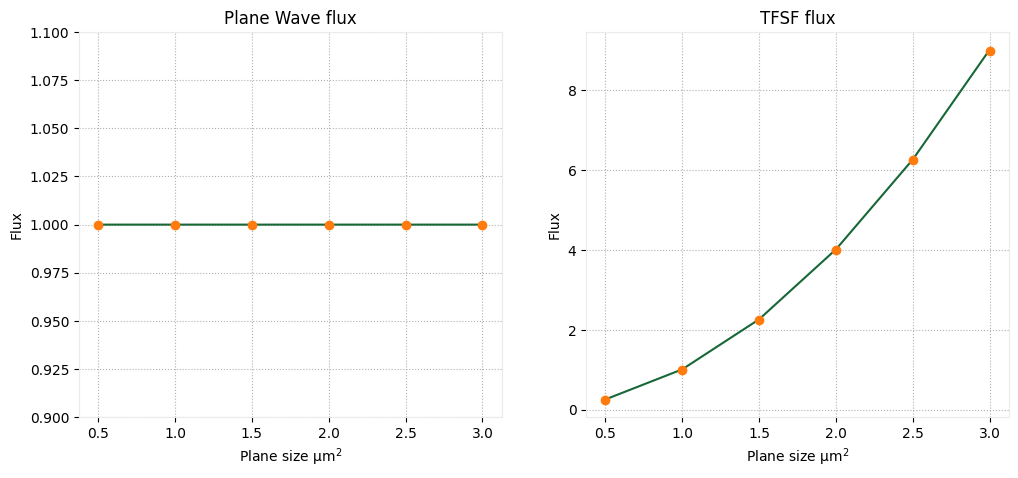

In [7]:
# visualizing the results
fig, Ax = plt.subplots(1, 2, figsize=(12, 5))

Ax[0].plot(sizes, flux_PW)
Ax[0].plot(sizes, [1 for i in sizes], "o")
Ax[0].set_ylim(0.9, 1.1)
Ax[0].set_title("Plane Wave flux")
Ax[0].set_xlabel("Plane size µm$^2$")
Ax[0].set_ylabel("Flux")

Ax[1].plot(sizes, flux_TFSF)
Ax[1].plot(sizes, [s**2 for s in sizes], "o")
Ax[1].set_title("TFSF flux")
Ax[1].set_xlabel("Plane size µm$^2$")
Ax[1].set_ylabel("Flux")


plt.show()

As shown in the figure above, the flux of the `PlaneWave` does not vary with the plane size, whereas it does for the `TFSF`.

Below, we illustrate the behavior of the electric field amplitude $|E_0|$, which exhibits the opposite trend.

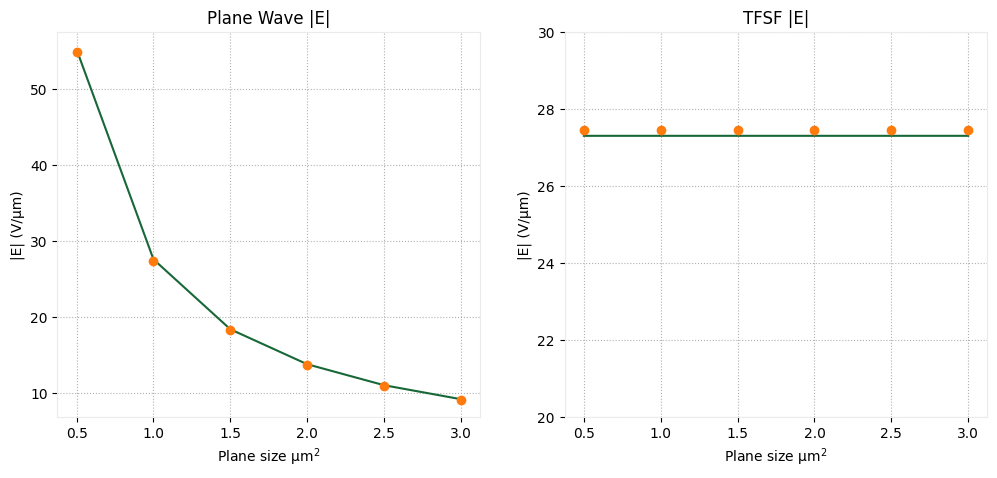

In [8]:
fig, Ax = plt.subplots(1, 2, figsize=(12, 5))

Ax[0].plot(sizes, E_PW)
Ax[0].plot(sizes, E0_PW, "o")

Ax[0].set_title("Plane Wave |E|")
Ax[0].set_xlabel("Plane size µm$^2$")
Ax[0].set_ylabel("|E| (V/µm)")

Ax[1].plot(sizes, E_TFSF)
Ax[1].plot(sizes, E0_TFSF, "o")
Ax[1].set_title("TFSF |E|")
Ax[1].set_xlabel("Plane size µm$^2$")
Ax[1].set_ylabel("|E| (V/µm)")
Ax[1].set_ylim(20, 30)

plt.show()

## Monitor Placement <a name="normalization"></a>

When dealing with forward and backward waves, it is important to carefully consider the monitor type and its position, specially at moderate resolutions (around 10 steps per wavelength). When using `ModeMonitors` or `DiffractionMonitors`, as demonstrated below, the error increases when the monitor needs to resolve forward and backward propagating fields with similar magnitudes.

Therefore, for highly reflective structures, it is preferable to place the monitors behind the source, where the forward-propagating field dominates. This helps minimize errors in the normalization process.

Here we will illustrate this issue with a plane wave incident in a dielectric interface.

In [9]:
# medium for the dielectric interface
medium = td.Medium(permittivity=3.5**2)

# defining FluxMonitors and DiffractionMonitors for computing the flux
structure = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-100, -100, -100), rmax=(100, 100, 0)), medium=medium
)
# flux monitor behind the source
flux_mon_back = td.FluxMonitor(
    name="flux_mon_back",
    size=(td.inf, td.inf, 0),
    center=(0, 0, -1.5),
    freqs=[freq0],
)
# flux monitor in front of the source
flux_mon_front = td.FluxMonitor(
    name="flux_mon_front",
    size=(td.inf, td.inf, 0),
    center=(0, 0, -0.5),
    freqs=[freq0],
)

# diffraction monitor behind the source
diff_mon_back = td.DiffractionMonitor(
    name="diff_mon_back",
    size=(td.inf, td.inf, 0),
    center=(0, 0, -1.5),
    freqs=[freq0],
    normal_dir="-",
)
# diffraction monitor in front of the source
diff_mon_front = td.DiffractionMonitor(
    name="diff_mon_front",
    size=(td.inf, td.inf, 0),
    center=(0, 0, -0.5),
    freqs=[freq0],
    normal_dir="-",
)

# normalization monitor in front of the source
norm_monitor = td.DiffractionMonitor(
    name="norm_monitor",
    size=(td.inf, td.inf, 0),
    center=(0, 0, -0.5),
    freqs=[freq0],
)

monitors = [flux_mon_back, flux_mon_front, diff_mon_back, diff_mon_front, norm_monitor]

In [10]:
# create simulations for different angles until total internal reflection
thetas2 = [0, 5, 10, 15, 20]
sims_PW_ref = {}

for t in thetas2:
    sim = get_sim(
        source_type="PW",
        theta_degree=t,
        bloch_medium=medium,
        pol_angle_degree=90,
        structures=[structure],
        min_steps_per_wvl=10,
    )
    sims_PW_ref[t] = sim.updated_copy(monitors=monitors)

batch_PW_ref = web.Batch(simulations=sims_PW_ref, folder_name="plane_wave_ref")

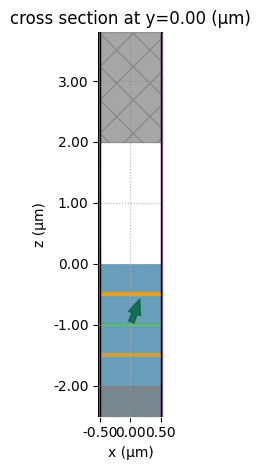

In [11]:
# visualizing the simulation setup
sims_PW_ref[20].plot(y=0)

plt.show()

In [12]:
# running the batch
batch_data_PW_ref = batch_PW_ref.run()

Output()

13:23:36 -03 Started working on Batch containing 5 tasks.

13:24:50 -03 Maximum FlexCredit cost: 0.125 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

13:24:54 -03 Batch complete.

Output()

In [13]:
# function for calculating the analytical Fresnel reflection coefficient for s-polarized light
def fresnel_rs(n1, n2, theta_i_deg):
    theta_i = np.radians(theta_i_deg)
    theta_t = np.arcsin(n1 * np.sin(theta_i) / n2 + 0j)
    r_s = (n1 * np.cos(theta_i) - n2 * np.cos(theta_t)) / (
        n1 * np.cos(theta_i) + n2 * np.cos(theta_t)
    )

    return abs(r_s) ** 2

In [14]:
# computing the reflection
reflection_analytic = fresnel_rs(3.5, 1, thetas2)

flux_front = np.array([batch_data_PW_ref[str(t)]["flux_mon_front"].flux for t in thetas2]).flatten()
flux_back = np.array([batch_data_PW_ref[str(t)]["flux_mon_back"].flux for t in thetas2]).flatten()

diff_front = np.array(
    [batch_data_PW_ref[str(t)]["diff_mon_front"].power.sum() for t in thetas2]
).flatten()
diff_back = np.array(
    [batch_data_PW_ref[str(t)]["diff_mon_back"].power.sum() for t in thetas2]
).flatten()

norm = np.array([batch_data_PW_ref[str(t)]["norm_monitor"].power.sum() for t in thetas2]).flatten()

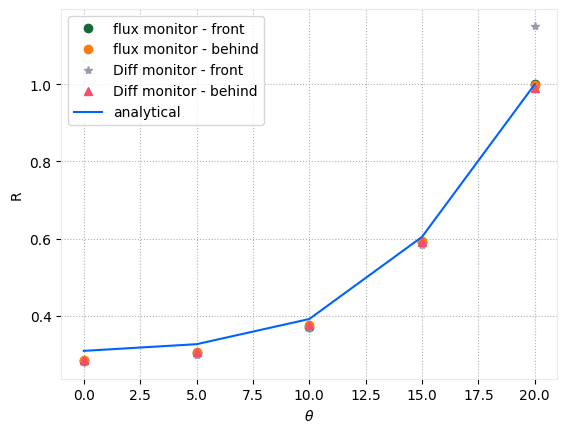

In [25]:
# visualizing the results
fig, ax = plt.subplots()
ax.plot(thetas2, 1 - flux_front, "o", label="flux monitor - front")
ax.plot(thetas2, -flux_back, "o", label="flux monitor - behind")

ax.plot(thetas2, diff_front, "*", label="Diff monitor - front")

ax.plot(thetas2, diff_back, "^", label="Diff monitor - behind")

ax.plot(thetas2, reflection_analytic, label="analytical")

ax.legend()

ax.set_ylabel("R")
ax.set_xlabel("$\\theta$")

plt.show()

Now we can compare the relative error across the different monitors. As shown, the error for the `DiffractionMonitor` placed in front of the source is higher compared to the other monitors, especially at high reflectances.

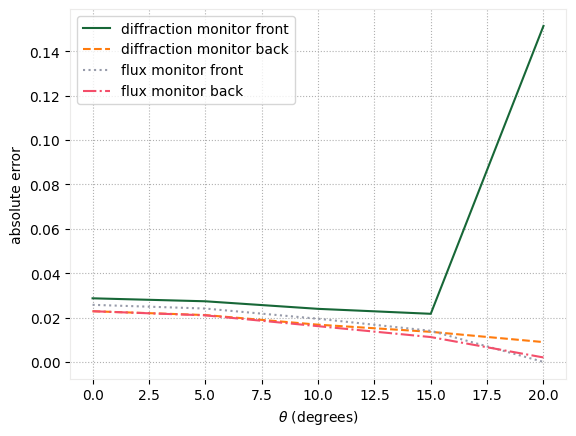

In [16]:
# comparing the error with different monitors
fig, ax = plt.subplots()
ax.plot(thetas2, abs(reflection_analytic - diff_front), "-", label="diffraction monitor front")
ax.plot(thetas2, abs(reflection_analytic - diff_back), "--", label="diffraction monitor back")
ax.plot(thetas2, abs(reflection_analytic - (1 - flux_front)), ":", label="flux monitor front")
ax.plot(thetas2, abs(reflection_analytic - (-flux_back)), "-.", label="flux monitor back")
ax.set_xlabel("$\\theta$ (degrees)")
ax.set_ylabel("absolute error")
ax.legend()

plt.show()

Hence, the `Diffraction` monitor will have a high error as a normalization monitor in the presence of both forward and backward propagation fields.

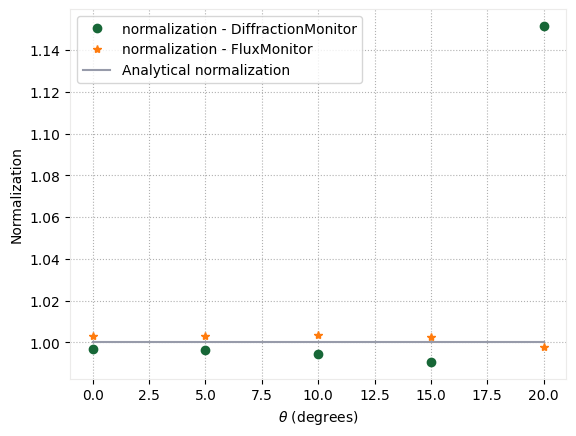

In [17]:
fig, ax = plt.subplots()
ax.plot(thetas2, norm, "o", label="normalization - DiffractionMonitor")
ax.plot(thetas2, flux_front - flux_back, "*", label="normalization - FluxMonitor")
ax.plot(thetas2, [1 for i in thetas2], label="Analytical normalization")
ax.legend()
ax.set_xlabel("$\\theta$ (degrees)")
ax.set_ylabel("Normalization")

plt.show()

### Increasing resolution

Now, we investigate the relative error for the `DiffractionMonitor` and `FluxMonitor` as a function of the resolution.

In [18]:
# create simulations for different angles until total internal reflection
resolutions = [10, 20, 30, 40]
sims_PW_res = {}

for r in resolutions:
    sim = get_sim(
        source_type="PW",
        theta_degree=20,
        bloch_medium=medium,
        pol_angle_degree=90,
        structures=[structure],
        min_steps_per_wvl=r,
    )
    sims_PW_res[r] = sim.updated_copy(monitors=monitors)

batch_PW_res = web.Batch(simulations=sims_PW_res, folder_name="plane_wave_ref")

In [19]:
batch_data_PW_res = batch_PW_res.run()

Output()

13:25:28 -03 Started working on Batch containing 4 tasks.

13:26:29 -03 Maximum FlexCredit cost: 0.892 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

13:26:32 -03 Batch complete.

Output()

In [20]:
# computing the reflection
flux_front_res = np.array(
    [batch_data_PW_res[str(r)]["flux_mon_front"].flux for r in resolutions]
).flatten()
diff_front_res = np.array(
    [batch_data_PW_res[str(r)]["diff_mon_front"].power.sum() for r in resolutions]
).flatten()

error_flux = [abs(i - reflection_analytic[-1]) for i in (1 - flux_front_res)]
error_diff = [abs(i - reflection_analytic[-1]) for i in diff_front_res]

As we can see, the error for the `DiffractionMonitor` rapidly decreases with increasing resolution. However, it remains slightly higher than that of the `FluxMonitor`.

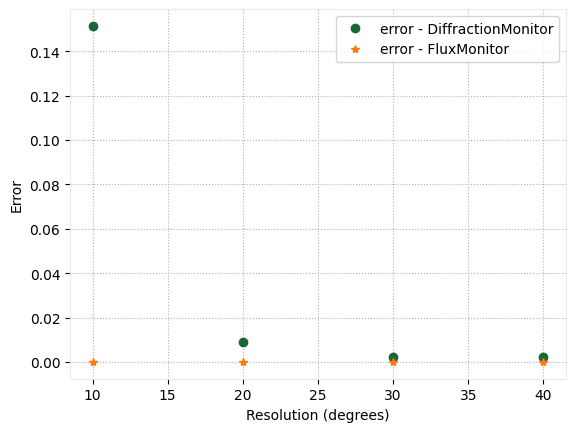

In [21]:
fig, ax = plt.subplots()
ax.plot(resolutions, error_diff, "o", label="error - DiffractionMonitor")
ax.plot(resolutions, error_flux, "*", label="error - FluxMonitor")
ax.legend()
ax.set_xlabel("Resolution (degrees)")
ax.set_ylabel("Error")

plt.show()

## Dipole Source <a name="dipole"></a>

The dipole source follows a different normalization scheme compared to other sources. Its spectral power is governed by the analytical expression for a classical radiating dipole, which is **not constant with respect to frequency.**

The frequency dependence of the radiated power follows:

$$P(\nu) = \frac{\mu_0 n}{12\pi c} (2\pi \nu)^2$$
where:
- $\mu_0$ is the permeability of free space,
- $n$ is the refractive index of the medium,
- $c$ is the speed of light,
- $\nu$ is the frequency.

Unlike sources like plane waves or total-field scattered-field (TFSF) sources, which are typically normalized through their power or amplitude across frequency, the dipole source spectrum reflects the physical reality of how an oscillating dipole behaves.

A quick example is shown below:


In [22]:
# dipole source
dipole = td.PointDipole(center=(0, 0, 0), source_time=source_time, polarization="Ez")

freqs = np.linspace(freq0 - fwidth, freq0 + fwidth, 101)

# flux monitor around the dipole source
flux_mon = td.FluxMonitor(
    name="flux_mon",
    size=(1, 1, 1),
    center=(0, 0, 0),
    freqs=freqs,
)
sim_pd = get_sim(size=3, source_type="TFSF")
sim_pd = sim_pd.updated_copy(size=(3, 3, 3), sources=[dipole], monitors=[flux_mon])
sim_data_pd = web.run(sim_pd, "point_dipole")

13:26:41 -03 Created task 'point_dipole' with task_id                           
             'fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=11433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=757173;https://tidy3d.simulation.cloud/workbench?taskId=fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb\taskId]8;;\]8;id=11433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb\=]8;;\]8;id=407424;https://tidy3d.simulation.cloud/workbench?taskId=fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb\fdve]8;;\]8;id=11433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb\-20e41888-35a]8;;\
             ]8;id=11433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-20e41888-35a5-450d-b98b-b13b6f0df7cb\5-450d-b98b-b13b6f0df7cb']8;;\.

             Task folder: ]8;id=894752;https://tidy3d.simulation.cloud/folders/folder-2d594d1c-257b-417d-92d0-e6dcb36d63f0\'default']8;;\.

Output()

13:26:57 -03 Maximum FlexCredit cost: 0.283. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

13:26:59 -03 status = success

Output()

13:27:00 -03 loading simulation from simulation_data.hdf5

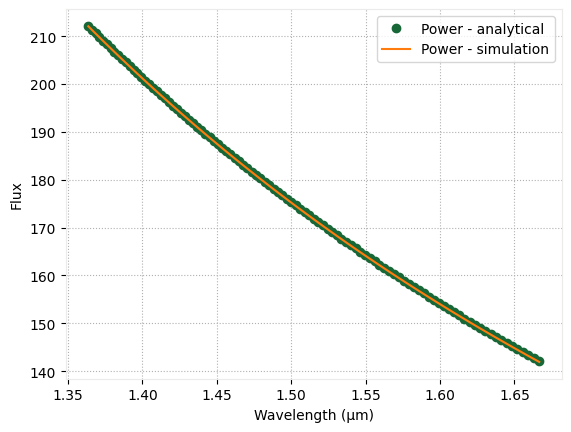

In [23]:
# visualizing the results
flux = [(td.MU_0 / (12 * np.pi * td.C_0)) * (2 * np.pi * f) ** 2 for f in freqs]
wvls = td.C_0 / freqs

fig, ax = plt.subplots()
ax.plot(wvls, flux, "o", label="Power - analytical")
ax.plot(wvls, sim_data_pd["flux_mon"].flux, label="Power - simulation")
ax.legend()
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Flux")

plt.show()